## Столбчатые диаграммы (Bar charts)

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 

## 1 Установливаем соединение с базой данных.

In [2]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Пронализируем пользователей из таблицы checker.

In [3]:
query = """
SELECT  uid, 
        timestamp
FROM checker
WHERE uid LIKE 'user_%'
ORDER BY uid ASC
"""
checker = pd.io.sql.read_sql(query, conn)

display(checker)

,uid,timestamp
0,user_0,2020-04-20 17:56:45.209722
1,user_0,2020-04-20 17:56:58.021415
2,user_0,2020-04-20 17:56:58.195472
3,user_1,2020-04-26 17:06:18.462708
4,user_1,2020-04-26 17:06:58.256753
...,...,...
3202,user_8,2020-05-14 21:12:17.314337
3203,user_8,2020-05-16 17:56:15.755553
3204,user_8,2020-05-16 17:57:48.867254
3205,user_8,2020-05-16 17:57:49.126243


## 3 Приведем таблицу в более удобный вид с часами и днями недели.

In [4]:
checker['timestamp'] = pd.to_datetime(checker['timestamp'])
checker['hour'] = checker['timestamp'].dt.hour
checker['weekday'] = checker['timestamp'].dt.weekday
checker['date'] = checker['timestamp'].dt.date
display(checker)

,uid,timestamp,hour,weekday,date
0,user_0,2020-04-20 17:56:45.209722,17,0,2020-04-20
1,user_0,2020-04-20 17:56:58.021415,17,0,2020-04-20
2,user_0,2020-04-20 17:56:58.195472,17,0,2020-04-20
3,user_1,2020-04-26 17:06:18.462708,17,6,2020-04-26
4,user_1,2020-04-26 17:06:58.256753,17,6,2020-04-26
...,...,...,...,...,...
3202,user_8,2020-05-14 21:12:17.314337,21,3,2020-05-14
3203,user_8,2020-05-16 17:56:15.755553,17,5,2020-05-16
3204,user_8,2020-05-16 17:57:48.867254,17,5,2020-05-16
3205,user_8,2020-05-16 17:57:49.126243,17,5,2020-05-16


## 4 Для каждого часа вычислим среднее количество коммитов в рабочие дни и выходные. Если в течение часа не было коммитов, не будем использовать это время для вычисления среднего значения.

In [5]:
workdays = checker[(checker['weekday'] >= 0) & (checker['weekday'] <= 4)]
weekends = checker[(checker['weekday'] == 5) | (checker['weekday'] == 6)]

workdays_grouped = workdays.groupby(['hour', 'date'])['uid'].count().reset_index(name='count')
weekends_grouped = weekends.groupby(['hour', 'date'])['uid'].count().reset_index(name='count')

display(workdays_grouped.head())
display(weekends_grouped.head())


,hour,date,count
0,0,2020-04-23,2
1,0,2020-05-14,4
2,3,2020-04-27,2
3,5,2020-04-17,13
4,5,2020-04-30,2


,hour,date,count
0,0,2020-04-19,2
1,0,2020-04-26,2
2,0,2020-05-10,2
3,1,2020-05-10,6
4,3,2020-04-25,1


In [6]:
avg_workdays = workdays_grouped.groupby('hour')['count'].mean().round().astype(int).reset_index(name='working_day')
avg_weekends = weekends_grouped.groupby('hour')['count'].mean().round().astype(int).reset_index(name='weekend')

hours = pd.DataFrame({'hour': range(24)})

avg_workdays = hours.merge(avg_workdays, on='hour', how='left').fillna(0)
avg_weekends = hours.merge(avg_weekends, on='hour', how='left').fillna(0)

display(avg_workdays.head())
display(avg_weekends.head())

,hour,working_day
0,0,3.0
1,1,0.0
2,2,0.0
3,3,2.0
4,4,0.0


,hour,weekend
0,0,2.0
1,1,6.0
2,2,0.0
3,3,1.0
4,4,0.0


## 5 Построим столбчатые диаграммы.

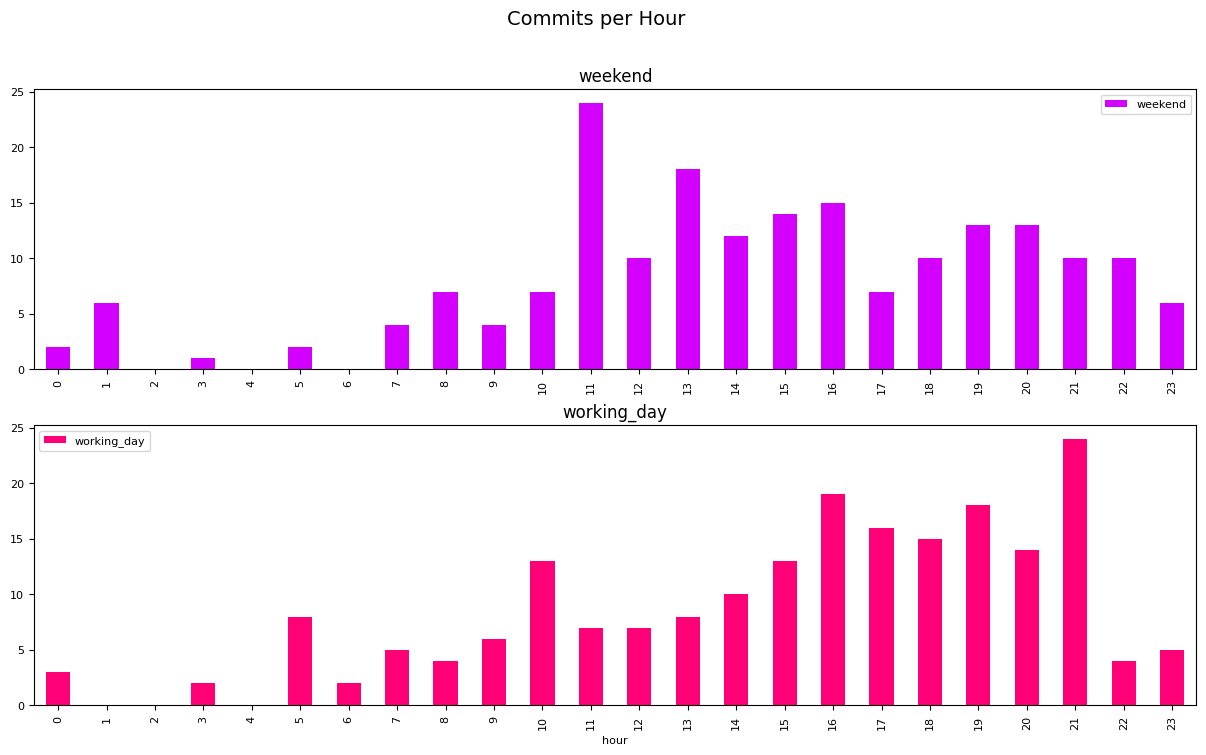

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
avg_weekends.plot(
    x='hour',
    y='weekend',
    kind='bar', 
    fontsize=8,
    color="#D400FF",
    title = 'weekend',
    ax=axes[0]
)

avg_workdays.plot(
    x='hour',
    y='working_day',
    kind='bar', 
    fontsize=8,
    color="#FF0077",
    title = 'working_day',
    ax=axes[1]
)

fig.suptitle('Commits per Hour', fontsize=14)

axes[0].set_xlabel('', fontsize=8)
axes[0].set_ylabel('', fontsize=8)
axes[0].legend(loc='upper right', fontsize=8)

axes[1].set_xlabel('hour', fontsize=8)
axes[1].set_ylabel('', fontsize=8)
axes[1].legend(loc='upper left', fontsize=8),

plt.show()

## 6 Отличается ли динамика в рабочие дни и выходные?

In [8]:
max_workday_hour = avg_workdays.loc[avg_workdays['working_day'].idxmax(), 'hour']
max_weekend_hour = avg_weekends.loc[avg_weekends['weekend'].idxmax(), 'hour']

print(f"Максимальное количество коммитов в рабочие дни приходится на")
print(max_workday_hour, "час")
print(f"Максимальное количество коммитов в выходные дни приходится на")
print(max_weekend_hour, "часов")

Максимальное количество коммитов в рабочие дни приходится на
21 час
Максимальное количество коммитов в выходные дни приходится на
11 часов


## 7 Закроем соединение с базой данных.

In [9]:
conn.close()